In [17]:
import EFC_learningfMRI.util as util
import EFC_learningfMRI.globals as gl
import os
import numpy as np
import PcmPy as pcm
import matplotlib.pyplot as plt
import EFC_learningfMRI.vis as vis
import pandas as pd
import seaborn as sb
import itertools
import statsmodels.formula.api as smf

# Crossnobis dissimilarities in absolute force and absolute force derivative
The RDMs show an example participant

In [18]:
# pick one example participant and list the chords they trained
sn     = 103                        
chords = util.get_trained_and_untrained(sn)
path   = os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}')

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

print(f'subj{sn}: trained {chords[:4]}, untrained {chords[4:]}')

subj103: trained ['92122', '21911', '12291', '21291'], untrained ['91211', '22911', '12129', '11911']


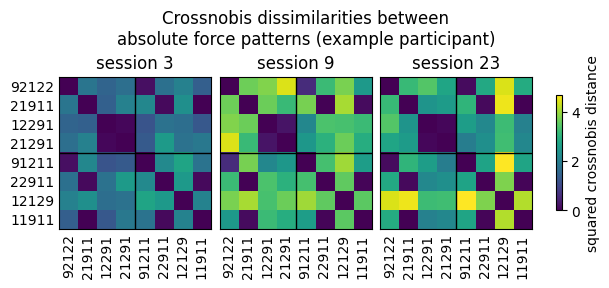

In [19]:
metric = 'abs'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

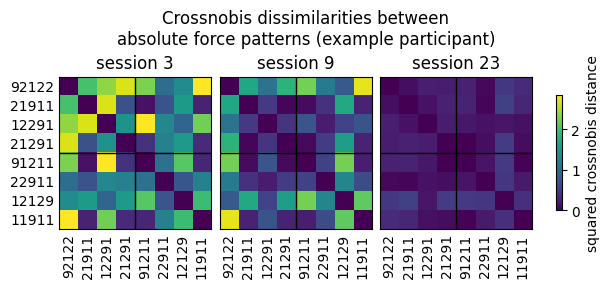

In [20]:
# example participant: dissimilarities between absolute force derivative patterns, one matrix per session

metric = 'der'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

/tmp/ipykernel_406077/993645489.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='lower right')


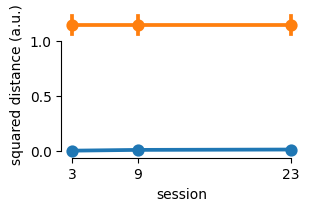

In [40]:
dist_force = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity_ancova.within_session.force.tsv'), sep='\t')
dist_force = dist_force[dist_force.chord.isin(hue_order)]
dist_force_g = dist_force.groupby(['sn', 'session', 'chord', 'metric']).mean(numeric_only=True).reset_index()
dist_force_g.session = dist_force_g.session.astype(int)

fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='cosine_slope_chord', errorbar='se',  native_scale=True)
sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='cosine_slope_group', errorbar='se',  native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=ax, trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)


# Average crossnobis dissimilarities and angles between trained and untrained chords 
## Absolute force

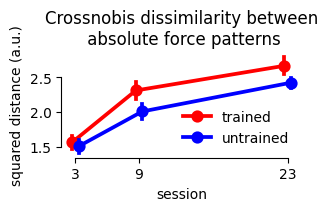

In [21]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='abs'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=ax, trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity between\n absolute force patterns')

plt.show()

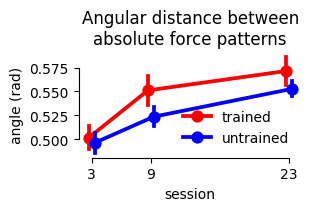

In [22]:
dist_force_g['theta'] = np.arccos(np.clip(1 - dist_force_g.cosine, -1, 1))

fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='abs'], x='session', y='theta', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('angle (rad)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Angular distance between\nabsolute force patterns')

plt.show()

## Absolute force derivative

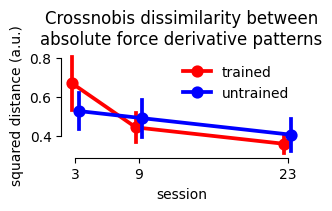

In [23]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity between\nabsolute force derivative patterns')

plt.show()

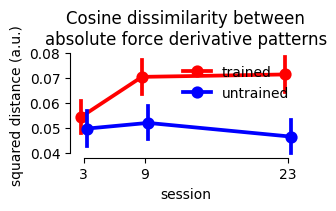

In [35]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='cosine', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='best')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Cosine dissimilarity between\nabsolute force derivative patterns')

plt.show()

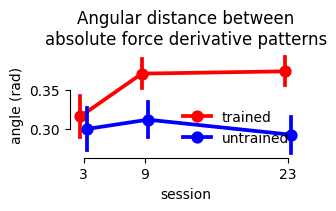

In [24]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='theta', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True, estimator='mean')
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('angle (rad)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Angular distance between\nabsolute force derivative patterns')

plt.show()

# Intercept analysis

The angular distance between absolute force derivative patterns (and to a lesser degree the crossnobis distance between absolute force patterns) showed pattern separation that was stronger in traned vs. untrained chords. A linear regression was fitted across participants between the average angle difference (trained - untrained) in neural activity patterns and asbolute force derivative patterns. A similar analysis was performed between average crossnobis dissimilarity difference (trained - untrained) in neural activity patterns and asbolute force patterns. The intercept in session 23 was significant in M1 and S1, suggesting a genuine pattern separation in this regions.

/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3   0.004350 -0.035724  0.044423  0.232805  0.819282
3         PMd        3   0.005450 -0.026255  0.037156  0.368707  0.717862
6         PMv        3  -0.006704 -0.048322  0.034914 -0.345504  0.734852
9          M1        3  -0.004229 -0.033930  0.025471 -0.305410  0.764548
12         S1        3   0.001685 -0.027456  0.030825  0.123989  0.903086
15       SPLa        3  -0.015160 -0.055258  0.024938 -0.810868  0.431011
18       SPLp        3  -0.003810 -0.044583  0.036962 -0.200433  0.844024
1         SMA        9  -0.004625 -0.045371  0.036121 -0.243460  0.811180
4         PMd        9  -0.008331 -0.060211  0.043549 -0.346903  0.734215
7         PMv        9  -0.014078 -0.067759  0.039604 -0.562459  0.582698
10         M1        9   0.013970 -0.034113  0.062054  0.623155  0.543201
13         S1        9   0.028205 -0.022638  0.079047  1.189814  0.253906
16       SPLa        9   0.008532 -0.0

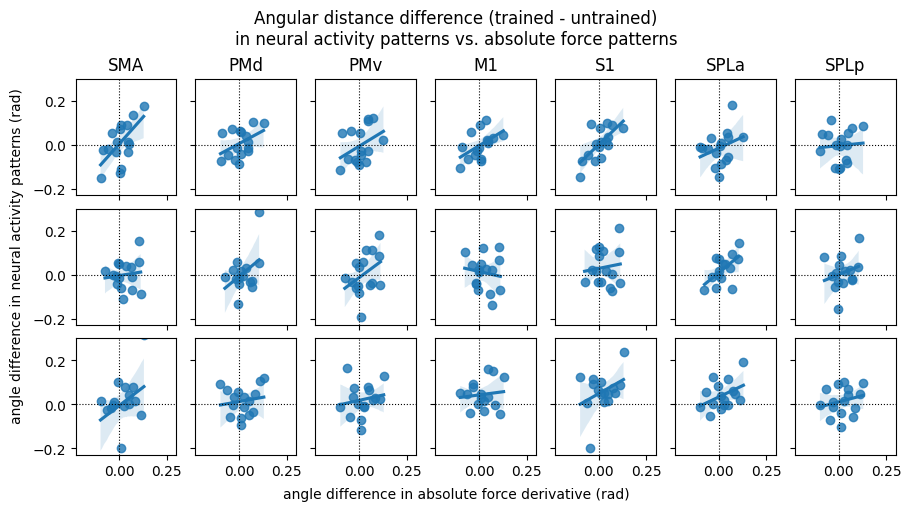

In [25]:
# difference in neural dissimilarities
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'theta'

dist_neural = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_neural = dist_neural[(dist_neural.Hem=='L') & (dist_neural.chord.isin(hue_order))]
dist_neural_g = dist_neural.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

dist_neural_g['theta'] = np.arccos(1 - dist_neural_g.cosine)

diff_neural = util.diff_trained_untrained(dist_neural_g, stat, on=['session', 'sn', 'roi', 'Hem'])

# difference in force dissimilarities
dist_force_g_der = dist_force_g[dist_force_g.metric=='abs']
diff_force  = util.diff_trained_untrained(dist_force_g_der, stat, on=['session', 'sn'])
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].Diff.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('neural~force', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.set_ylim([-.23, .3])
                ax.set_xlim([-.23, .3])
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('angle difference in neural activity patterns (rad)', fontsize=10)
fig.supxlabel('angle difference in absolute force derivative (rad)', fontsize=10)

fig.suptitle('Angular distance difference (trained - untrained)\nin neural activity patterns vs. absolute force patterns')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

In [ ]:
# difference in neural dissimilarities
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'theta'

dist_neural = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_neural = dist_neural[(dist_neural.Hem=='L') & (dist_neural.chord.isin(hue_order))]
dist_neural_g = dist_neural.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

# cross-validated cosine distances can be slightly negative, which puts 1 - cosine outside the arccos domain
dist_neural_g['theta'] = np.arccos(np.clip(1 - dist_neural_g.cosine, -1, 1))

diff_neural = util.diff_trained_untrained(dist_neural_g, stat, on=['session', 'sn', 'roi', 'Hem'])

# difference in force dissimilarities
dist_force_g_der = dist_force_g[dist_force_g.metric=='der']
diff_force  = util.diff_trained_untrained(dist_force_g_der, stat, on=['session', 'sn'])

# one model per ROI across sessions: common slope, one intercept per session (C(session) coefficients).
records   = []
for r, roi in enumerate(rois):
        d    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi)][['sn', 'session', 'Diff']]
        f    = diff_force[['sn', 'session', 'Diff']]
        data = d.merge(f, on=['sn', 'session'], suffixes=('_neural', '_force')).rename(columns={'Diff_neural': 'neural', 'Diff_force': 'force'})

        res = smf.ols('neural ~ force + C(session) - 1', data=data, groups=data.sn).fit()

        ci = res.conf_int()

        for sess in gl.sessions:

                term = f'C(session)[{sess}]'

                records.append({
                        'regionname': roi,
                        'session':    sess,
                        'intercept':  res.params[term],
                        'se':         res.bse[term],
                        'ci_low':     ci.loc[term, 0],
                        'ci_high':    ci.loc[term, 1],
                        #'tval':       res.tvalues[term],
                        'pval':       res.pvalues[term],
                        #'slope':      res.params['force'],
                })
                
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

   regionname  session  intercept        se    ci_low   ci_high      pval
0         SMA        3   0.004617  0.023022 -0.041780  0.051014  0.841968
3         PMd        3   0.004505  0.018109 -0.031991  0.041001  0.804697
6         PMv        3  -0.006879  0.020188 -0.047565  0.033806  0.734902
9          M1        3  -0.003700  0.016778 -0.037514  0.030115  0.826508
12         S1        3   0.000035  0.017444 -0.035121  0.035191  0.998406
15       SPLa        3  -0.016481  0.016927 -0.050595  0.017634  0.335567
18       SPLp        3  -0.006629  0.017499 -0.041897  0.028639  0.706648
1         SMA        9  -0.018639  0.024013 -0.067033  0.029756  0.441786
4         PMd        9  -0.014560  0.018888 -0.052627  0.023508  0.444932
7         PMv        9  -0.007414  0.021057 -0.049851  0.035024  0.726464
10         M1        9   0.000219  0.017501 -0.035052  0.035490  0.990071
13         S1        9   0.010930  0.018195 -0.025740  0.047599  0.551116
16       SPLa        9   0.000772  0.0

/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)
/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)
/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)
/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)
/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)
/home/UWO/memanue5/Documents/GitHub

In [33]:
# planned analysis: neural ~ force within one session, for a few ROIs
rois = ['M1', 'S1', 'SPLa']
sess = 23

records = []
for roi in rois:
        d    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)][['sn', 'Diff']]
        f    = diff_force[diff_force.session==sess][['sn', 'Diff']]
        data = d.merge(f, on='sn', suffixes=('_neural', '_force')).rename(columns={'Diff_neural': 'neural', 'Diff_force': 'force'})

        res = smf.ols('neural ~ force', data=data).fit()
        ci  = res.conf_int()

        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'se':         res.bse['Intercept'],
                'ci_low':     ci.loc['Intercept', 0],
                'ci_high':    ci.loc['Intercept', 1],
                'pval':       res.pvalues['Intercept'],
        })

intercepts = pd.DataFrame(records)

print(intercepts)


  regionname  session  intercept        se    ci_low   ci_high      pval
0         M1       23   0.032475  0.018942 -0.008153  0.073102  0.108500
1         S1       23   0.020250  0.020634 -0.024005  0.064504  0.343059
2       SPLa       23   0.025370  0.018070 -0.013385  0.064126  0.182102


In [27]:
# bootstrap CIs: resample subjects with replacement (all sessions of a subject stay together),
# refit the same OLS (neural ~ force + C(session) - 1) and take the 2.5/97.5 percentiles of each coefficient
n_boot = 5000
rng    = np.random.default_rng(0)
terms  = ['force'] + [f'C(session)[{sess}]' for sess in gl.sessions]

boot_records = []
for roi in rois:
        d    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi)][['sn', 'session', 'Diff']]
        f    = diff_force[['sn', 'session', 'Diff']]
        data = d.merge(f, on=['sn', 'session'], suffixes=('_neural', '_force')).rename(columns={'Diff_neural': 'neural', 'Diff_force': 'force'})

        # same design as the formula: force column + one dummy per session (no global intercept)
        X    = np.c_[data.force.to_numpy(), (data.session.to_numpy()[:, None] == np.array(gl.sessions)).astype(float)]
        y    = data.neural.to_numpy()
        subj = data.sn.unique()
        rows = [np.flatnonzero(data.sn.to_numpy()==sn) for sn in subj]

        beta = np.full((n_boot, len(terms)), np.nan)
        for b in range(n_boot):
                idx     = np.concatenate([rows[i] for i in rng.integers(len(subj), size=len(subj))])
                beta[b] = np.linalg.lstsq(X[idx], y[idx], rcond=None)[0]

        est = np.linalg.lstsq(X, y, rcond=None)[0]
        for t, term in enumerate(terms):
                boot_records.append({
                        'regionname': roi,
                        'term':       term,
                        'estimate':   est[t],
                        'ci_low':     np.percentile(beta[:, t], 2.5),
                        'ci_high':    np.percentile(beta[:, t], 97.5),
                })
boot_ci = pd.DataFrame(boot_records)
print(boot_ci)


   regionname            term  estimate    ci_low   ci_high
0         SMA           force  0.303302 -0.284647  0.601158
1         SMA   C(session)[3]  0.004617 -0.038372  0.042661
2         SMA   C(session)[9] -0.018639 -0.050828  0.013549
3         SMA  C(session)[23] -0.017698 -0.069719  0.027961
4         PMd           force  0.211508 -0.196433  0.398263
5         PMd   C(session)[3]  0.004505 -0.025021  0.031497
6         PMd   C(session)[9] -0.014560 -0.048737  0.021617
7         PMd  C(session)[23] -0.001588 -0.036749  0.033267
8         PMv           force  0.185089 -0.132741  0.413964
9         PMv   C(session)[3] -0.006879 -0.041622  0.029951
10        PMv   C(session)[9] -0.007414 -0.049404  0.033634
11        PMv  C(session)[23]  0.006591 -0.021833  0.039610
12         M1           force  0.141383 -0.119001  0.245385
13         M1   C(session)[3] -0.003700 -0.032382  0.025792
14         M1   C(session)[9]  0.000219 -0.036593  0.036606
15         M1  C(session)[23]  0.033444 

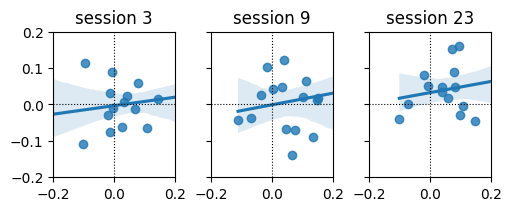

In [28]:
roi = 'M1'

fig, axs = plt.subplots(1, len(gl.sessions), constrained_layout=True, sharex=True, sharey=True, figsize=(5, 2))

for s, sess in enumerate(gl.sessions):
        ax = axs[s]
        y    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)].Diff.to_numpy()
        x    = diff_force[diff_force.session==sess].Diff.to_numpy()
        data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

        lin_model[(roi, sess)] = smf.ols('neural~force', data=data).fit()

        sb.regplot(data, x='force', y='neural', ax=ax)

        ax.set_title(f'session {sess}')
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_ylim([-.2, .2])
        ax.set_xlim([-.2, .2])
        ax.axhline(0, color='k', lw=.8, ls=':')
        ax.axvline(0, color='k', lw=.8, ls=':')

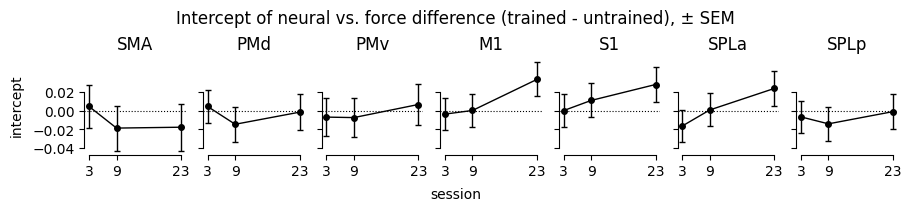

In [29]:
# time course of the regression intercept (± SEM) in each ROI
fig, axs = plt.subplots(1, len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 2))

for r, roi in enumerate(rois):
        ax  = axs[r]
        icp = intercepts[intercepts.regionname==roi].sort_values('session')

        ax.errorbar(icp.session, icp.intercept, yerr=icp.se, color='k', marker='o', ms=4, capsize=2, lw=1)
        ax.axhline(0, color='k', lw=.8, ls=':')

        ax.set_title(roi)
        ax.set_xticks(gl.sessions)
        sb.despine(ax=ax, trim=True)

fig.supylabel('intercept', fontsize=10)
fig.supxlabel('session', fontsize=10)
fig.suptitle('Intercept of neural vs. force difference (trained - untrained), ± SEM')

plt.show()